Question A

In [58]:
# Necessary imports
from matplotlib import pyplot as plt
import numpy as np
import math

In [49]:
# Data

time = [0, 0.54, 0.9, 1.23, 1.58, 1.95, 2.33, 2.7] # time midpoints
cell_conc = [15.5, 23, 30, 38.8, 48.5, 58.3, 61.3, 62.5] #cell conc midpoint 
lac_conc = [137, 137, 114, 90, 43, 29, 9, 2]

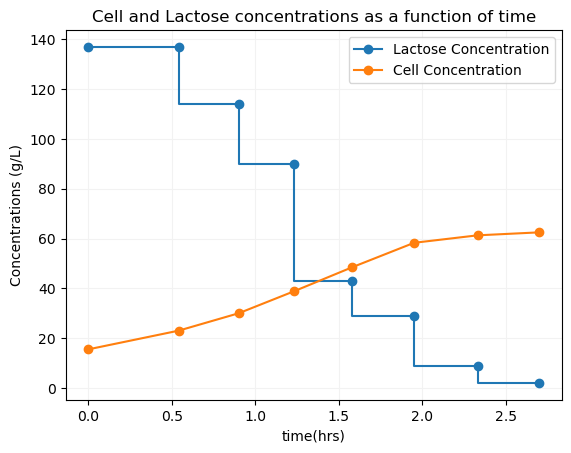

In [18]:
# Plotting the figure 
plt.figure()

plt.step(time, lac_conc,'o-', drawstyle='steps', label='Lactose Concentration')
plt.plot(time, cell_conc,'o-', label='Cell Concentration')

plt.grid(color='0.95')
plt.title('Cell and Lactose concentrations as a function of time')
plt.xlabel(xlabel='time(hrs)')
plt.ylabel(ylabel='Concentrations (g/L)')
plt.legend()
plt.show()

Zooming in on the cell concetration plot

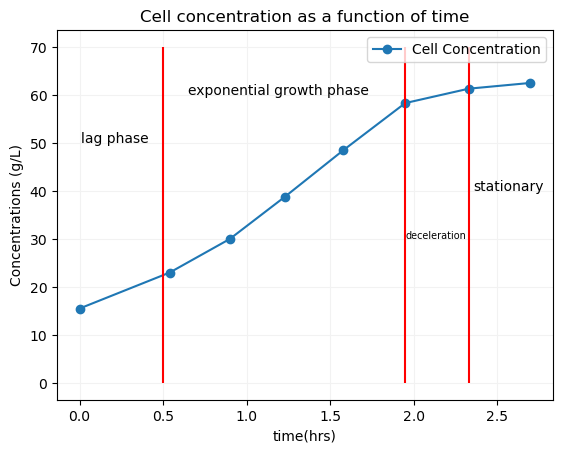

In [40]:
plt.figure()

plt.plot(time, cell_conc,'o-', label='Cell Concentration')

plt.vlines(0.5, 0, 70, color='red', linestyles='solid')
plt.vlines(1.95, 0, 70, color='red', linestyles='solid')
plt.vlines(2.33, 0, 70, color='red', linestyles='solid')
plt.text(0.01, 50, 'lag phase')
plt.text(0.65, 60, 'exponential growth phase')
plt.text(1.95, 30, 'deceleration', fontsize=7)
plt.text(2.36, 40, 'stationary')

plt.grid(color='0.95')
plt.title('Cell concentration as a function of time')
plt.xlabel(xlabel='time(hrs)')
plt.ylabel(ylabel='Concentrations (g/L)')
plt.legend()
plt.show()

The expected batch growth phases are the lag phase, exponential growth phase, deceleration phase and stationary phase. On our graph, we can hardly identify the lag phase which is most likely due to the assumption of linear growth during an interval. We can assume that the lag phase lasted somewhere between 0.0 and 0.5h where the increase is smaller compared to the increase from 0.5h until 1.95h which we identify as the exponential growth phase during which the lactose is abundant and cells grow at a maximum growth rate which explains the steep slope. The deceleration phase then follows as lactose concentration drops sharply and substrate limitation sets in. Lastly, the stationary phase follows after approximately 2.3h which is characterized by a plateau explained by the lactose being nearly depleted. The phases have been identified on the graph.   

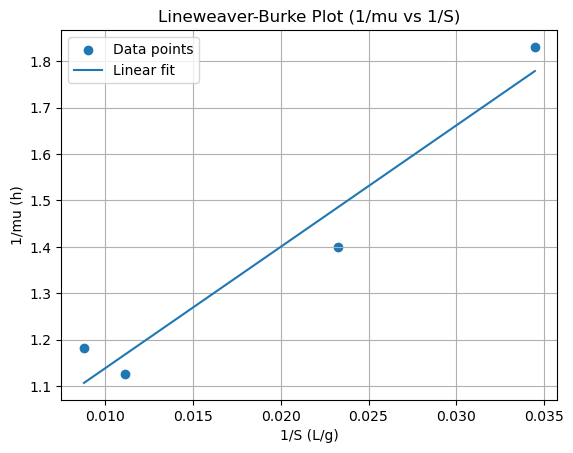


Estimated Monod parameters:
mu_max = 1.13999 1/h
K_s   = 29.81615 g/L


In [57]:
# Time intervals (h)
t_intervals = [(0.54,0.9),(0.9,1.23),(1.23,1.58),
               (1.58,1.95)]

# Biomass (g/L)
X_start = np.array([23, 30, 38.8, 48.5])
X_end   = np.array([30, 38.8, 48.5, 58.3])

# Substrate (lactose) concentration (g/L)
S = np.array([114, 90, 43, 29])

# Calculations
dt = np.array([t[1]-t[0] for t in t_intervals])

# dX/dt
dXdt = (X_end - X_start) / dt

# mu calculation
mu = (1 / X_start) * dXdt

# Lineweaver-Burke variables
inv_mu = 1 / mu
inv_S = 1 / S

# Linear regression
slope, intercept = np.polyfit(inv_S, inv_mu, 1)

# Kinetic parameters
mu_max = 1 / intercept
Ks = slope * mu_max

# Plot
plt.figure()
plt.scatter(inv_S, inv_mu, label="Data points")
plt.plot(inv_S, slope*inv_S + intercept, label="Linear fit")
plt.xlabel("1/S (L/g)")
plt.ylabel("1/mu (h)")
plt.title("Lineweaver-Burke Plot (1/mu vs 1/S)")
plt.grid(True)
plt.legend()
plt.show()

# Output
print("\nEstimated Monod parameters:")
print(f"mu_max = {mu_max:.5f} 1/h")
print(f"K_s   = {Ks:.5f} g/L")

Question B

Doubling time is a property of the organism under optimal conditions, therefore we will use mu_max since it is the maximum specific growth rate. Mu_max was calculated previously. 

In [62]:
doubling_time = math.log(2)/mu_max
print("td = ", doubling_time,"hrs")

td =  0.6080295141280456 hrs
